In [29]:
import numpy as np
import pandas as pd

In [30]:
df = pd.read_csv(
    "D:/Python/Python_Learning/Machine_Learning/End_to_End_ML_Project/placement.csv"
)

In [31]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [23]:
df.shape

(100, 4)

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       100 non-null    float64
 1   iq         100 non-null    float64
 2   placement  100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


In [25]:
# Steps

# 0. Preprocess + EDA + Feature Selection
# 1. Extract input and output cols
# 2. Scale the values
# 3. Train test split
# 4. Train the model
# 5. Evaluate the model/model selection
# 6. Deploy the model

In [33]:
df = df.iloc[:,1:]
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [34]:
import matplotlib.pyplot as plt

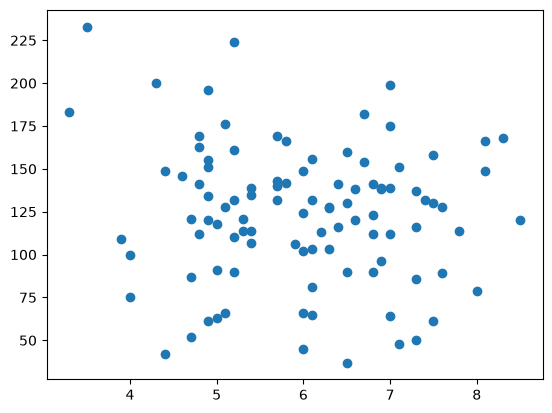

In [37]:
plt.scatter(df['cgpa'],df['iq'])

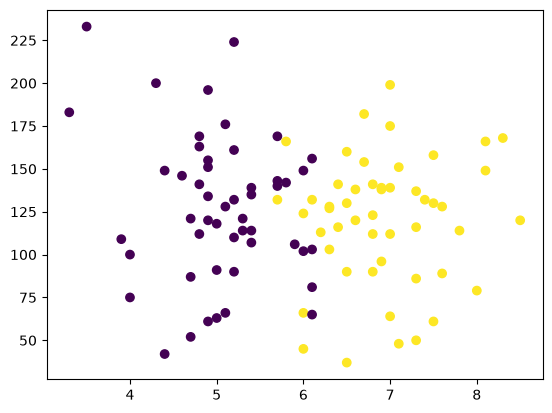

In [38]:
plt.scatter(df['cgpa'],df['iq'], c = df['placement'])

In [39]:
x = df.iloc[:, :2]
y = df.iloc[:, -1]

In [40]:
x

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [41]:
y

0     1
1     0
2     0
3     1
4     0
     ..
95    0
96    0
97    1
98    1
99    1
Name: placement, Length: 100, dtype: int64

In [44]:
from sklearn.model_selection import train_test_split

In [46]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.1)

In [49]:
x_train[:10]

,cgpa,iq
71,6.1,132.0
69,8.5,120.0
86,5.1,128.0
61,7.3,137.0
97,6.7,182.0
24,4.7,121.0
6,5.7,143.0
62,6.0,102.0
11,6.9,138.0
17,3.3,183.0


In [50]:
x_test[:10]

,cgpa,iq
32,7.0,139.0
46,5.3,114.0
25,5.0,91.0
45,6.0,66.0
10,6.0,45.0
27,6.0,124.0
68,4.0,75.0
19,5.2,132.0
60,6.9,139.0
76,4.9,155.0


In [55]:
y_train

71    1
69    1
86    0
61    1
97    1
     ..
73    0
12    0
85    1
63    1
16    0
Name: placement, Length: 90, dtype: int64

In [56]:
y_test

32    1
46    0
25    0
45    1
10    1
27    1
68    0
19    0
60    1
76    0
Name: placement, dtype: int64

In [57]:
from sklearn.preprocessing import StandardScaler

In [58]:
scaler = StandardScaler()

In [59]:
x_train = scaler.fit_transform(x_train)

In [61]:
x_train[:10]

array([[ 0.05959676,  0.1677172 ],
       [ 2.13587111, -0.1331708 ],
       [-0.80551755,  0.0674212 ],
       [ 1.09773393,  0.2930872 ],
       [ 0.57866535,  1.42141721],
       [-1.15156327, -0.1080968 ],
       [-0.28644896,  0.4435312 ],
       [-0.02691467, -0.5845028 ],
       [ 0.75168821,  0.3181612 ],
       [-2.3627233 ,  1.44649121]])

In [63]:
x_test = scaler.fit_transform(x_test)

In [64]:
x_test[:10]

array([[ 1.5531123 ,  0.89081931],
       [-0.37410734,  0.17241664],
       [-0.71420493, -0.48851381],
       [ 0.41945369, -1.20691648],
       [ 0.41945369, -1.81037473],
       [ 0.41945369,  0.45977771],
       [-1.84786354, -0.94829152],
       [-0.4874732 ,  0.68966656],
       [ 1.43974644,  0.89081931],
       [-0.82757079,  1.35059702]])

In [65]:
from sklearn.linear_model import LogisticRegression

In [66]:
clf = LogisticRegression()

In [68]:
# model training
clf.fit(x, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [69]:
# model evaluate
clf.predict(x_test)

D:\Python\Python_Learning\.env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [70]:
y_pred =  clf.predict(x_test)

D:\Python\Python_Learning\.env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [71]:
y_test

32    1
46    0
25    0
45    1
10    1
27    1
68    0
19    0
60    1
76    0
Name: placement, dtype: int64

In [74]:
from sklearn.metrics import accuracy_score

In [75]:
accuracy_score(y_test, y_pred)

0.5

In [77]:
from mlxtend.plotting import plot_decision_regions

D:\Python\Python_Learning\.env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


<Axes: >

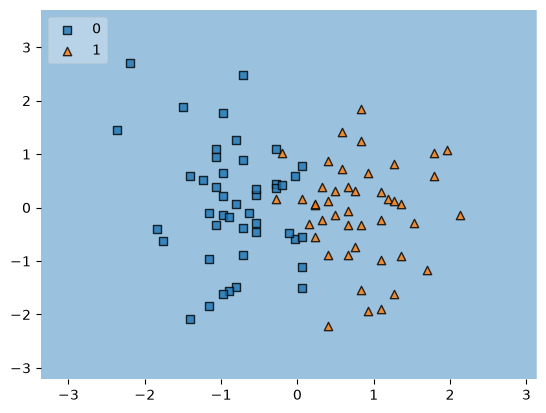

In [79]:
plot_decision_regions(x_train, y_train.values, clf=clf, legend=2)

In [80]:
import pickle

In [81]:
pickle.dump(clf, open('model.pkl', 'wb'))